In [46]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
# geopandas extends pandas to handle geospatial data and perform operations on geographic shapes.
import geopandas as gpd
# matplotlib.colors provides tools to define and manipulate colormaps for visualizations.
import matplotlib.colors as mcolors
# ListedColormap allows the creation of custom colormaps for visualizations.
from matplotlib.colors import ListedColormap
from pathlib import Path
from typing import List
from matplotlib.patches import Patch
from scipy.signal import find_peaks
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.optimize import nnls
#import matplotlib.colormaps as cm
import matplotlib.markers as mmarkers
import matplotlib.cm as cm

In [2]:


def collect_files(base_dir: str, dirs: List[str], subpath: str, pattern: str, exclude: str = None) -> List[str]:
    """
    Collects files matching a pattern from specified subdirectories.

    Parameters:
        base_dir (str): Base directory containing all subdirectories.
        dirs (List[str]): List of subdirectory names.
        subpath (str): Relative path inside each subdirectory where files are located.
        pattern (str): Glob pattern to match files.
        exclude (str, optional): String pattern to exclude from results.

    Returns:
        List[str]: Sorted list of matching file paths as strings.
    """
    all_files = []
    for d in dirs:
        search_path = Path(base_dir) / d / subpath / pattern
        files = sorted(search_path.parent.glob(search_path.name))
        if exclude:
            files = [f for f in files if exclude not in f.name]
        all_files.extend([str(f) for f in files])
    return all_files

# Base directory and subdirectories
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]

# Collect files
core_processed_files = collect_files(base_dir, dirs, "core_processed", "core_faam*r1*.nc", exclude="_1hz")
dry_neph_files = collect_files(base_dir, dirs, "mo-non-core", "metoffice*neph1*.nc")
flight_sum_files = collect_files(base_dir, dirs, ".", "flight-sum*.txt")
sp2_files = collect_files(base_dir, dirs, "non-core", "man-sp2*.na")
ams_files = collect_files(base_dir, dirs, "non-core", "man-ams*.na")
lidar_files = collect_files(base_dir, dirs, "non-core", "met*.nc")
core_processed_files_cloud = collect_files(base_dir, dirs, "core_processed", "core-cloud*r0*.nc")
#core-cloud-phy_faam_20120920_v500_r0_b737#

# Example: print or pass them into other analysis
# print(core_processed_files)


In [3]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_core = {extract_flight_number(f) for f in core_processed_files}
flights_ams = {extract_flight_number(f) for f in dry_neph_files}
flights_sp2 = {extract_flight_number(f) for f in sp2_files}
flights_neph = {extract_flight_number(f) for f in ams_files}
flights_cloud = {extract_flight_number(f) for f in core_processed_files_cloud}

# Find flights that are in all three datasets
common_flights = flights_core & flights_ams & flights_sp2 & flights_neph & flights_cloud # Set intersection

# Filter the file lists to include only matching flights
filtered_core = [f for f in core_processed_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in ams_files if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in sp2_files if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in dry_neph_files if extract_flight_number(f) in common_flights]
filtered_cloud = [f for f in core_processed_files_cloud if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered Core files: {len(flights_core)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_neph)}")
print(f"Filtered Cloud files: {len(filtered_cloud)}")

Common flights: ['b734', 'b737', 'b739', 'b740', 'b741', 'b742', 'b743', 'b744', 'b745', 'b746', 'b747', 'b748', 'b749', 'b750']
Filtered Core files: 19
Filtered AMS files: 14
Filtered SP2 files: 14
Filtered Neph files: 14
Filtered Cloud files: 14


In [4]:
def geometric_mean_diameter(D_lower, D_upper, concentrations):
    """
    Compute geometric mean diameter (µm) from channel boundaries and concentrations.
    """
    # Bin midpoints in log-space
    D_mid = np.sqrt(D_lower * D_upper)

    # Ensure concentrations is numpy array and mask invalids
    concentrations = np.array(concentrations, dtype=float)
    mask = (concentrations > 0) & (concentrations != 9999)

    if not np.any(mask):
        #print('retornou')
        return np.nan  # no valid data

    conc = concentrations[mask]
    D_mid = D_mid[mask]

    # Weighted geometric mean
    log_Dg = np.nansum(conc * np.log(D_mid)) / np.nansum(conc)
    return np.exp(log_Dg)

In [5]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds_t = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds_t])

    dsf = dsf.assign_coords(time=dsf['neph_spm'])
    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))
    #dsf["Times"] = (("time",), datetime_values)
    #dsf["datetime"] = (("time",), datetime_values)
    #dsf = dsf.set_coords('neph_spm')

    return dsf

In [6]:
def dataset_sp2_ams_neph(file_path_sp2,file_path_ams,file_path_neph):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )
 
    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None


    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams,ds_neph

In [7]:
def Nc_file_treatment_v2(aux_ds_sp2, aux_ds_ams, aux_ds_psap):
    import numpy as np
    import xarray as xr

    variables = ["SO4", "NH4", "ORG", "NO3", "Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    # Prepare individual valid masks and apply them
    resampled_vars = {}
    resampled_uncs = {}

    for var in variables:
        valid_mask = (aux_ds_ams[var] != 9999999) & (aux_ds_ams[var] >= 0)
        filtered = aux_ds_ams[var].where(valid_mask)
        resampled_vars[var] = filtered.resample(datetime="30s").mean()

    for unc in variables_unc:
        resampled_uncs[unc] = aux_ds_ams[unc].resample(datetime="30s").mean()

    # Process BC_mass
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2["BC_mass"].where(valid_BC_mass_mask) * 1e-3  # Convert to µg/m³
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="30s").mean()

    # Sum only valid AMS components at each time
    total_mass_ams = sum(v.fillna(0) for v in resampled_vars.values())

    # Sum only available AMS uncertainties (quadrature)
    total_uncertainty_ams = np.sqrt(sum((resampled_uncs[unc].fillna(0))**2 for unc in variables_unc))

    # Total BC mass (only one component here)
    total_mass_bc = resampled_ds_sp2

    # Combine AMS + BC total mass
    total_mass = total_mass_ams + total_mass_bc

    # PSAP filtering
    resampled_psap = aux_ds_psap.resample(Time='30s').mean()
    valid_PSAP_mask = (
        (resampled_psap["CO_AERO_FLAG"] == 0) 
#        (resampled_psap["CO_AERO"] >= 160) &
#        (resampled_psap["GPS_ALT"] <= 3000) &
#        (resampled_psap["GPS_ALT"] >= 200)
    )
    filtered_ds_psap = resampled_psap.where(valid_PSAP_mask, drop=False)
    filtered_ds_psap_aux = resampled_psap.where(valid_PSAP_mask, drop=True)

    # Match times
    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])
    total_mass_matched = total_mass.sel(time=common_times)
    total_mass_matched_uncertainty = total_uncertainty_ams.sel(time=common_times)
    #ds_psap_matched = filtered_ds_psap.sel(data_point=common_times)

    # Create auxiliary PSAP dataset with matching times
    psap_time = filtered_ds_psap_aux['data_point'].values
    mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])
    ds_psap_matched_aux = filtered_ds_psap_aux.where(mask, drop=True)

    # Optional mass breakdowns
    amonium_sulfate_nitrate = (
        resampled_vars["SO4"] +
        resampled_vars["NH4"] +
        resampled_vars["NO3"]
    )
    org = resampled_vars["ORG"]
    bc_mass = resampled_ds_sp2

    data_masses = [bc_mass, amonium_sulfate_nitrate, org]

    return ds_psap_matched_aux, total_mass_matched, total_mass_matched_uncertainty, ds_psap_matched_aux, data_masses


In [8]:
def growth_func_calc(ds_nc):
    
    # Extract the dew point and time
    T_dew_K = ds_nc['TDEW_GE']  # Dew point temperature in Kelvin
    time = ds_nc['data_point']  # Time variable
    # Extract the True air temperature and time
    T_air_K = ds_nc['TAT_DI_R']  # True air temperature in Kelvin with shape (20998, 32)
    
    # Convert 'Time' to a pandas datetime index for resampling
    # Ensure the 'Time' variable is in seconds or a similar time unit that pandas can work with
    time_index = pd.to_datetime(time.values, unit='s')
    
    T_dew_flat = T_dew_K.values.flatten()
    time_flat_dew = time_index.repeat(T_dew_K.shape[1])  # Repeat the time values for each frequency (4Hz)
    
    
    # Create a pandas DataFrame for easier resampling
    df = pd.DataFrame({'Time': time_flat_dew, 'TDEW_GE': T_dew_flat})
    
    # Resample the data by 1 minute and calculate the mean for each interval
    df_resampled = df.resample('30s', on='Time').mean()
    
    # Convert the resampled dew point temperature back to an xarray
    T_dew_resampled = xr.DataArray(df_resampled['TDEW_GE'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})
    
    # Step 2: Create a pandas DataFrame for resampling
    # Flatten the TAT_DI_R array to make it 1D for DataFrame construction
    T_air_flat = T_air_K.values.flatten()
    time_flat_air = time_index.repeat(T_air_K.shape[1])  # Repeat the time values for each frequency (32Hz)
    
    # Create a DataFrame with the flattened arrays
    df = pd.DataFrame({'Time': time_flat_air, 'TAT_DI_R': T_air_flat})
    
    # Step 3: Resample the data by 1 minute and compute the mean for each time interval
    df_resampled = df.resample('30s', on='Time').mean()
    
    # Step 4: Convert back to xarray
    T_air_resampled = xr.DataArray(df_resampled['TAT_DI_R'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})

    # Convert from Kelvin to Celsius
    T_dew_resampled_C = T_dew_resampled - 273.15
    
    # Convert from Kelvin to Celsius
    T_air_resampled_C = T_air_resampled - 273.15
    
    # Convert to Celsius
    T_dew_C = T_dew_resampled_C
    T_air_C = T_air_resampled_C
    
    # Calculate relative humidity using the Magnus formula
    RH = 100 * (np.exp((17.625 * T_dew_C) / (243.04 + T_dew_C)) /
                np.exp((17.625 * T_air_C) / (243.04 + T_air_C)))

    alpha = 0.15
    fh = (1-(RH)/100)**(-alpha)


    return fh

In [9]:
def calculate_scatering_eff_v2(aux_ds_sp2,aux_ds_ams,aux_ds_neph):

    # List of variables to check for invalid values
    variables = ["SO4", "NH4", "ORG", "NO3","Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    #(aux_ds_sp2["BC_mass"] != 9999999) & (aux_ds_sp2["BC_mass"] >= 0)
    # Build a combined valid mask using xarray operations
    valid_mask = (aux_ds_ams[variables[0]] != 9999999) & (aux_ds_ams[variables[0]] >= 0)
    for var in variables[1:]:
        valid_mask = valid_mask & (aux_ds_ams[var] != 9999999)  & (aux_ds_ams[var]  >= 0)
    
    # Apply the combined mask to the whole dataset
    filtered_ds = aux_ds_ams.where(valid_mask, drop=True)

    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass"] = filtered_ds_BC_mass["BC_mass"] * 1e-3

    # Resample to 1-minute means
    resampled_ams = filtered_ds.resample(datetime="30s").mean()
    resampled_neph = aux_ds_neph.resample(datetime='30s').mean()
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="30s").mean()

    #print(resampled_ds['time'].shape)
    #print(resampled_ds_sp2['BC_mass'].shape)

    # Calculate total mass across selected components
    total_mass_ams = sum(resampled_ams[var] for var in variables)
    #print(total_mass_ams)
    total_mass_bc = sum(resampled_ds_sp2[var] for var in components)
    #print(total_mass)
    total_mass = total_mass_ams + total_mass_bc

    # Compute total uncertainty (quadrature sum)
    total_uncertainty_ams = np.sqrt(sum((resampled_ams[unc] ** 2 for unc in variables_unc)))
    total_uncertainty = total_uncertainty_ams  # Assuming BC_mass has no uncertainty provided

    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])

    
    total_mass_matched = total_mass.sel(time=common_times)
    ds_neph_matched = resampled_neph.sel(time=common_times)
    total_mass_matched_uncertanty = total_uncertainty.sel(time=common_times)

    
    return ds_neph_matched,total_mass_matched,total_mass_matched_uncertanty

In [10]:

def extract_pcasp_geo_diameter(ds_core_cloud):
    """
    Compute geometric mean diameters from PCASP channels in ds_core_cloud.
    
    Parameters
    ----------
    ds_core_cloud : xarray.Dataset
        Dataset containing PCASP variables:
        - PCAS2_01 ... PCAS2_30
        - PCAS2_D_L_NOM, PCAS2_D_U_NOM
        - PCAS2TSPM (time coordinate)
    geometric_mean_diameter_func : callable
        Function to compute geometric mean diameter given
        (D_lower_limits, D_upper_limits, concentrations).
    
    Returns
    -------
    times : np.ndarray
        Array of time values.
    Dgs : np.ndarray
        Array of geometric mean diameters.
    """

    # Collect PCASP channels into one DataArray (channels x time)
    pcasp_channels = [f"PCAS2_{i:02d}" for i in range(1, 31)]
    da_pcasp = xr.concat([ds_core_cloud[v] for v in pcasp_channels], dim="PCAS2CH")

    # Replace invalid values (9999) with NaN
    da_pcasp = da_pcasp.where(da_pcasp != 9999)

    # Diameter bin limits
    D_lower_limits = ds_core_cloud['PCAS2_D_L_NOM'].values
    D_upper_limits = ds_core_cloud['PCAS2_D_U_NOM'].values

    # Loop through time to compute geometric mean diameters
    times = da_pcasp['PCAS2TSPM'].values
    geom_diam_list = []

    for t in times:
        snapshot = da_pcasp.sel(PCAS2TSPM=t)
        concentrations = snapshot.values
        Dg = geometric_mean_diameter(D_lower_limits, D_upper_limits, concentrations)
        geom_diam_list.append((t, Dg))

    # Unpack times and diameters
    times, Dgs = zip(*geom_diam_list)
    return da_pcasp, times, Dgs

In [11]:
def var_plot_landcover():
    # Open the dataset
    # Load the satellite dataset (e.g., MODIS data) using xarray. The dataset is in HDF format, 
    # so the "netcdf4" engine is specified to handle the file correctly.
    ds = xr.open_dataset('../MCD12C1.A2013001.061.2022165063153.hdf', engine="netcdf4")
    #MCD12C1.A2012001.061.2022162172724.hdf
    
    # Sort the Y-axis in descending order
    ds = ds.sortby("YDim:MOD12C1", ascending=False)
    
    # Generate latitude and longitude arrays
    # Create a latitude array with values ranging from -90 to 90, evenly spaced for 3600 points.
    # This corresponds to the number of points along the YDim:MOD12C1 dimension of the dataset.
    latitude = np.linspace(-90, 90, 3600)  # For YDim:MOD12C1
    
    # Create a longitude array with values ranging from -180 to 180, evenly spaced for 7200 points.
    # This corresponds to the number of points along the XDim:MOD12C1 dimension of the dataset.
    longitude = np.linspace(-180, 180, 7200)  # For XDim:MOD12C1
    
    # Assign latitude and longitude as coordinates with explicit dimensions
    # Use the `assign_coords` method to add the generated latitude and longitude arrays
    # as coordinates to the dataset. The "latitude" array is tied to the YDim:MOD12C1 dimension,
    # and the "longitude" array is tied to the XDim:MOD12C1 dimension.
    ds = ds.assign_coords({
        "latitude": ("YDim:MOD12C1", latitude), 
        "longitude": ("XDim:MOD12C1", longitude)
    })
    
    # Replace the existing dimensions with the newly assigned coordinates
    # The `swap_dims` method is used to replace the YDim:MOD12C1 dimension with "latitude"
    # and the XDim:MOD12C1 dimension with "longitude". This makes the dataset directly indexable
    # using latitude and longitude values instead of the original dimension labels.
    ds = ds.swap_dims({"YDim:MOD12C1": "latitude", "XDim:MOD12C1": "longitude"})
    
    
    # Define the bounding box coordinates for a region of interest
    # These coordinates specify the minimum and maximum longitude (minlon, maxlon)
    # and latitude (minlat, maxlat) for the region you want to extract from the dataset.
    
    # Box 1: The bounding box covers a specific region in the Amazon area
    #minlon, maxlon, minlat, maxlat = -72, -48, -11, -3  # Example box 1
    minlon, maxlon, minlat, maxlat = -66.5, -45.5, -12, -6  # Example box 2
    # ax3.set_extent([-66.5, -45.5, -12, -6], crs=ccrs.PlateCarree())
    
    ds_subset = ds.sel(
        latitude=slice(minlat, maxlat),  # Latitude slicing (descending order)
        longitude=slice(minlon, maxlon)  # Longitude slicing (ascending order)
    )
    
    # Define the land cover classes and their corresponding descriptive names
    # Each key in the dictionary represents a class number, and its value is the name of the land cover type.
    land_cover_classes = {
        0: "Water",
        1: "Evergreen Needleleaf Forest",
        2: "Evergreen Broadleaf Forest",
        3: "Deciduous Needleleaf Forest",
        4: "Deciduous Broadleaf Forest",
        5: "Mixed Forests",
        6: "Closed Shrubland",
        7: "Open Shrublands",
        8: "Woody Savannas",
        9: "Savannas",
        10: "Grasslands",
        11: "Permanent Wetlands",
        12: "Croplands",
        13: "Urban and Built-Up",
        14: "Cropland/Natural Vegetation Mosaic",
        15: "Snow and Ice",
        16: "Barren or Sparsely Vegetated",
    }
    
    # Define a list of custom colors corresponding to the land cover classes
    # These colors will be used in the plot to represent each class visually.
    custom_colors = [
        "blue",         # 0: Water
        "darkgreen",    # 1: Evergreen Needleleaf Forest
        "limegreen",    # 2: Evergreen Broadleaf Forest
        "yellowgreen",  # 3: Deciduous Needleleaf Forest
        "olivedrab",    # 4: Deciduous Broadleaf Forest
        "olive",        # 5: Mixed Forests
        "brown",        # 6: Closed Shrubland
        "peru",         # 7: Open Shrublands
        "tan",          # 8: Woody Savannas
        "khaki",        # 9: Savannas
        "gold",         # 10: Grasslands
        "aqua",         # 11: Permanent Wetlands
        "orange",       # 12: Croplands
        "red",          # 13: Urban and Built-Up
        "teal",         # 14: Cropland/Natural Vegetation Mosaic
        "white",        # 15: Snow and Ice
        "gray"          # 16: Barren or Sparsely Vegetated
    ]
    
    # Create a colormap using the custom colors
    # The colormap maps the land cover classes to the corresponding colors for visualization.
    custom_cmap = ListedColormap(custom_colors)
    
    # Define a normalization that maps class numbers to colors in the colormap
    # BoundaryNorm ensures the colors align correctly with the class boundaries.
    num_classes = len(land_cover_classes)  # Total number of land cover classes
    cmap = custom_cmap
    norm = mcolors.BoundaryNorm(
        boundaries=np.arange(-0.5, len(custom_colors) + 0.5, 1),  # Boundaries between classes
        ncolors=len(custom_colors)  # Total number of colors
    )
    
    # Define the classes that appear on the map (optional)
    # This is useful if not all classes are present in the region being plotted.
    active_classes = [0, 2, 4, 5, 8, 9, 10, 11, 12, 13]  # Example subset of active classes
    
    # Filter the land cover classes to include only the active classes
    # This creates a smaller dictionary with just the classes that are present.
    filtered_land_cover_classes = {k: land_cover_classes[k] for k in active_classes}
    #print(filtered_land_cover_classes)
    
    # Filter the colors to match the active classes
    # This ensures that the colormap contains only the colors for the active classes.
    filtered_colors = [custom_colors[k] for k in active_classes]
    #print(filtered_colors)
    
    # Create a new colormap using the filtered colors
    # The new colormap will include only the colors corresponding to the active classes.
    filtered_cmap = ListedColormap(filtered_colors)
    #print(filtered_cmap)
    
    # Update the normalization to match the filtered classes
    # This ensures that the color mapping aligns with the filtered colormap.
    norm2 = mcolors.BoundaryNorm(
        boundaries=np.arange(0, len(filtered_colors), 1),  # Adjust boundaries to the filtered classes
        ncolors=len(filtered_colors)  # Total number of filtered colors
    )

    # Define the file paths for shapefiles that contain geographical data
    cities_shapefile = "/home/jovyan/GOES-Fire-Inventory/Auxiliary Data/ne_10m_populated_places.shp"  # Cities shapefile
    roads_shapefile = "/home/jovyan/GOES-Fire-Inventory/Auxiliary Data/ne_10m_roads.shp"
    #"../GOES-Fire-Inventory/
    # Read the shapefiles for cities, roads, and urban areas into GeoDataFrames
    cities = gpd.read_file(cities_shapefile)
    roads = gpd.read_file(roads_shapefile)
    
    return minlon,maxlon,minlat,maxlat,roads,cities,ds_subset,cmap,norm,filtered_colors,filtered_land_cover_classes,active_classes

In [12]:
def add_land_cover_nc_file(nc_file,lancover_subset):

    # Extract the land cover map data
    lat_map = lancover_subset['latitude'].values
    lon_map = lancover_subset['longitude'].values
    land_cover = lancover_subset['Majority_Land_Cover_Type_1']
    
    # Initialize result list
    biomes = []
    
    # Tolerance in degrees
    tolerance = 0.05
    
    # Loop over aircraft positions
    for lat, lon in zip(nc_file['LAT_GPS'].values, nc_file['LON_GPS'].values):
        if np.isnan(lat) or np.isnan(lon):
            biomes.append(np.nan)
            continue
    
        # Find the index of the nearest lat/lon within the tolerance
        lat_diff = np.abs(lat_map - lat)
        lon_diff = np.abs(lon_map - lon)
    
        if np.min(lat_diff) <= tolerance and np.min(lon_diff) <= tolerance:
            nearest_lat = lat_map[np.argmin(lat_diff)]
            nearest_lon = lon_map[np.argmin(lon_diff)]
    
            biome = land_cover.sel(
                latitude=nearest_lat,
                longitude=nearest_lon
            ).values
            biomes.append(biome)
        else:
            # No point within tolerance
            biomes.append(np.nan)
    
    # Convert to DataArray
    biome_array = xr.DataArray(
        data=np.array(biomes),
        dims=["data_point"],
        coords={"data_point": nc_file["data_point"]},
        name="Biome_Type"
    )
    
    # Add to aircraft dataset
    nc_file = nc_file.assign(Biome_Type=biome_array)
    return nc_file

In [13]:
minlon,maxlon,minlat,maxlat,roads,cities,ds_subset,cmap,norm,filtered_colors,filtered_land_cover_classes,active_classes = var_plot_landcover()

In [14]:
#filtered_sp2 = sp2_files[6]
#filtered_ams = ams_files[2]
#filtered_neph = dry_neph_files[7]
#filtered_nc = core_processed_files[7]

In [15]:
filtered_cloud[2]

'/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core-cloud-phy_faam_20120923_v500_r0_b739.nc'

In [16]:
ds_core_cloud = xr.open_dataset(filtered_cloud[2])
da_pcasp, times, Dgs = extract_pcasp_geo_diameter(ds_core_cloud)

In [17]:
ds_core_cloud

<xarray.Dataset> Size: 19MB
Dimensions:         (Time: 27470, 2DTSPM: 27470, PCAS2CH: 30, PCAS2TSPM: 27470,
                     CDP_TSPM: 27470, CDPCH: 30)
Coordinates:
  * Time            (Time) datetime64[ns] 220kB 2012-09-23T08:24:18 ... 2012-...
  * 2DTSPM          (2DTSPM) datetime64[ns] 220kB 2012-09-23T08:24:17.500000 ...
  * PCAS2CH         (PCAS2CH) float32 120B 1.0 2.0 3.0 4.0 ... 28.0 29.0 30.0
  * PCAS2TSPM       (PCAS2TSPM) datetime64[ns] 220kB 2012-09-23T08:24:17.6992...
  * CDP_TSPM        (CDP_TSPM) datetime64[ns] 220kB 2012-09-23T08:24:17.51171...
  * CDPCH           (CDPCH) float32 120B 1.0 2.0 3.0 4.0 ... 27.0 28.0 29.0 30.0
Data variables: (12/181)
    2DC_CONC        (2DTSPM) float32 110kB ...
    2DC_CONC_FLAG   (2DTSPM) float32 110kB ...
    2DC_LWC         (2DTSPM) float32 110kB ...
    2DC_LWC_FLAG    (2DTSPM) float32 110kB ...
    2DC_IWC         (2DTSPM) float32 110kB ...
    2DC_IWC_FLAG    (2DTSPM) float32 110kB ...
    ...              ...
    CDP_D_L_NOM     (CDPCH) float32 120B ...
    CDP_D_U_NOM     (CDPCH) float32 120B ...
    CDP_D_L_CAL     (CDPCH) float32 120B ...
    CDP_D_U_CAL     (CDPCH) float32 120B ...
    CDP_D_L_ERR     (CDPCH) float32 120B ...
    CDP_D_U_ERR     (CDPCH) float32 120B ...
Attributes:
    Conventions:             CF-1.4
    title:                   Cloud Physics and Aerosol Data core-cloud-phy_fa...
    institution:             Facility for Airborne Atmospheric Measurements (...
    source:                  Aircraft measurement
    history:                 04-Dec-2012 - core-cloud-phy_faam_20120923_v500_...
    references:              www.faam.ac.uk\\nwww.badc.ac.uk
    comment:                 This data should be interpretted in association ...
    PMS2DC_Proc_Options:     Bulk quantities processed for bins 1 - 32;Comple...
    PMS2DC_MidBin_Diamater:  [37.5 62.5 87.5 112.5 137.5 162.5 187.5 212.5 23...

Max valid total concentration: 22006116.0


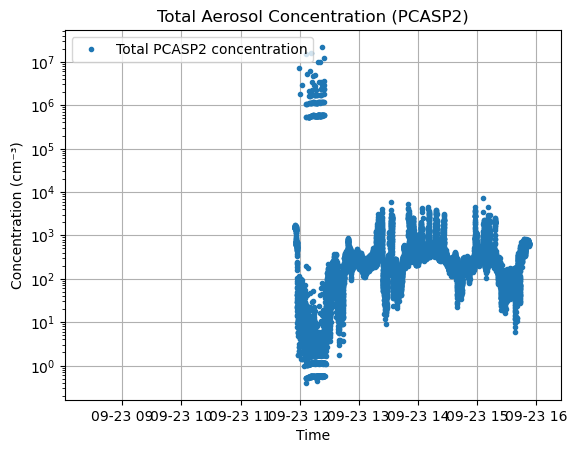

In [18]:
# Sum concentrations across channels (ignoring NaNs)
total_conc = da_pcasp.sum(dim="PCAS2CH", skipna=True)

print("Max valid total concentration:", np.nanmax(total_conc.values))

# Plot
plt.plot(total_conc['PCAS2TSPM'].values, total_conc.values,'.', label="Total PCASP2 concentration")

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Concentration (cm⁻³)")
plt.title("Total Aerosol Concentration (PCASP2)")
plt.grid(True)
plt.legend()
plt.show()

Max valid 1-min total concentration: 946614.9


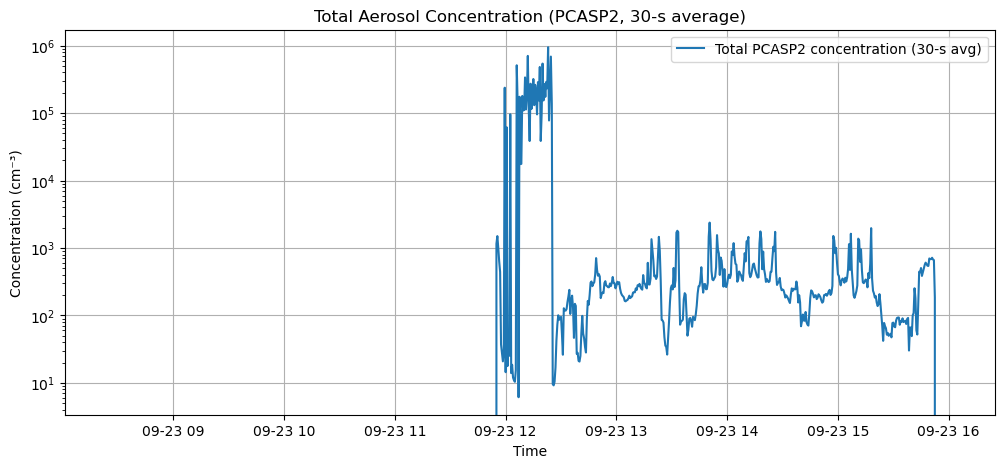

In [19]:
# Sum concentrations across channels (ignoring NaNs)
total_conc = da_pcasp.sum(dim="PCAS2CH", skipna=True)

# Resample to 1-minute averages
total_conc_1min = total_conc.resample(PCAS2TSPM="30s").mean(skipna=True)

print("Max valid 1-min total concentration:", np.nanmax(total_conc_1min.values))

# Plot
plt.figure(figsize=(12,5))
plt.plot(total_conc_1min['PCAS2TSPM'].values, total_conc_1min.values,
         label="Total PCASP2 concentration (30-s avg)")

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Concentration (cm⁻³)")
plt.title("Total Aerosol Concentration (PCASP2, 30-s average)")
plt.grid(True)
plt.legend()
plt.show()

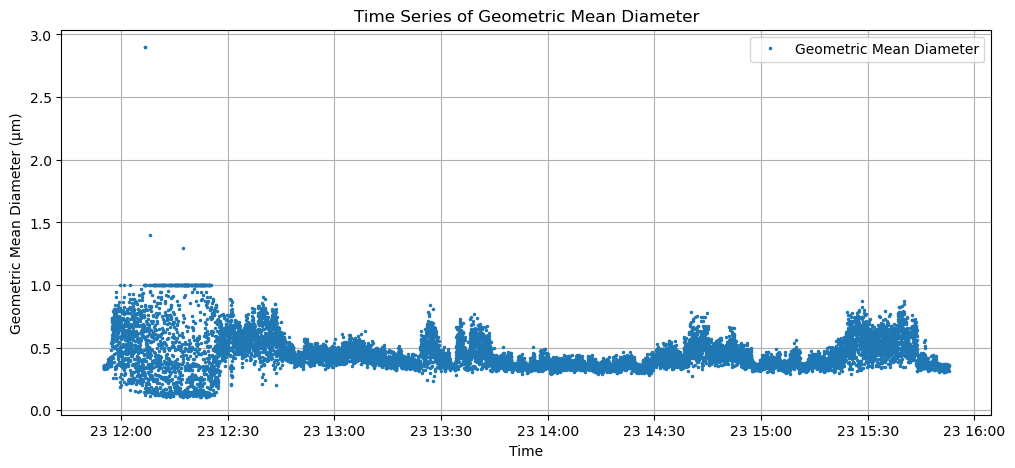

In [20]:
plt.figure(figsize=(12,5))
plt.plot(times, Dgs, ".", markersize=3, label="Geometric Mean Diameter")

plt.xlabel("Time")
plt.ylabel("Geometric Mean Diameter (µm)")
plt.title("Time Series of Geometric Mean Diameter")
plt.grid(True)
plt.legend()
plt.show()

In [21]:
filtered_neph[1]

'/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/mo-non-core/metoffice-neph1_faam_20120920_r1_b737.nc'

In [22]:
ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(filtered_sp2[2],filtered_ams[2],filtered_neph[2])
ds_core = xr.open_dataset(filtered_core[2])

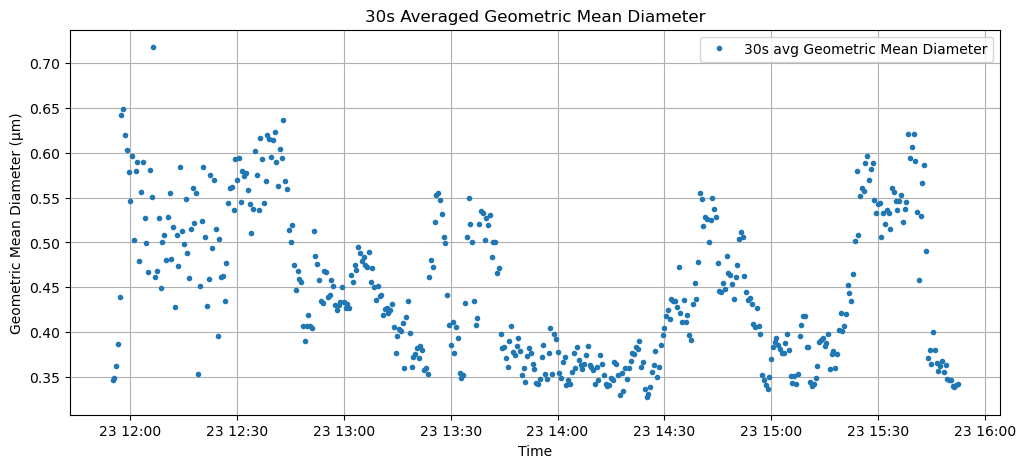

In [23]:

series = pd.Series(Dgs, index=pd.to_datetime(times))

# Resample to 1-minute mean
Dgs_1min = series.resample("30s").mean()

# Plot
plt.figure(figsize=(12,5))
plt.plot(Dgs_1min.index, Dgs_1min.values, "o", markersize=3, label="30s avg Geometric Mean Diameter")

plt.xlabel("Time")
plt.ylabel("Geometric Mean Diameter (µm)")
plt.title("30s Averaged Geometric Mean Diameter")
plt.grid(True)
plt.legend()
plt.show()

In [24]:
results_sct = []

ds_psap_matched,tm_psap_match,tm_psap_match_unc,test,data_masses=Nc_file_treatment_v2(ds_sp2,ds_ams,ds_core)
ds_neph_matched_un,tm_neph_match,tm_neph_match_unc=calculate_scatering_eff_v2(ds_sp2,ds_ams,ds_neph)


ds_psap_matched_time = test["data_point"].values  # Reference timestamps
ds_neph_matched_time = ds_neph_matched_un["time"].values
common_times = np.intersect1d(ds_psap_matched_time, ds_neph_matched_time)


core_file_matched = test.sel(data_point=common_times)
ds_neph_matched = ds_neph_matched_un.sel(time=common_times)
tm_neph_match = tm_neph_match.sel(time=common_times)
BC_mass_match = data_masses[0].sel(time=common_times)
amonium_sulfate_nitrate_mass_match = data_masses[1].sel(time=common_times)
ORG_mass_match = data_masses[2].sel(time=common_times)

CO_conc_matched = core_file_matched['CO_AERO'].values.squeeze()
TSC_blue = ds_neph_matched["TSC_BLUU"].values.squeeze()
TSC_green = ds_neph_matched["TSC_GRNU"].values.squeeze()
TSC_red = ds_neph_matched["TSC_REDU"].values.squeeze()

# Extract the flight number (b###) from the file path
match = re.search(r'b\d{3}', filtered_core[1])  # Looks for 'b' followed by 3 digits
flight_number = match.group(0) if match else "Unknown"
# Extract the date in yyyymmdd format
date_match = re.search(r'(\d{8})', filtered_core[1])
if date_match:
    date_str = date_match.group(1)
    flight_date = datetime.strptime(date_str, "%Y%m%d").strftime("%Y-%m-%d")
else:
    flight_date = "Unknown"

#series = pd.Series(Dgs, index=pd.to_datetime(times))
# Align Dg values with matched times
series = pd.Series(Dgs, index=pd.to_datetime(times))
#Dg_aligned_matched = series.reindex(pd.to_datetime(common_times), method="nearest")
Dgs_30s = series.resample("30s").mean()
Dg_matched = Dgs_30s.reindex(pd.to_datetime(common_times), method="nearest")
# Store results in a list
results_sct.append({
    'BC': BC_mass_match.values,
    'INO': amonium_sulfate_nitrate_mass_match.values,
    'ORG': ORG_mass_match.values,
    'DG_aligned': Dg_matched,
    'CO': CO_conc_matched,
    'TSC_blue':TSC_blue,
    'TSC_green':TSC_green,
    'TSC_red':TSC_red,
    'flight': flight_number
})


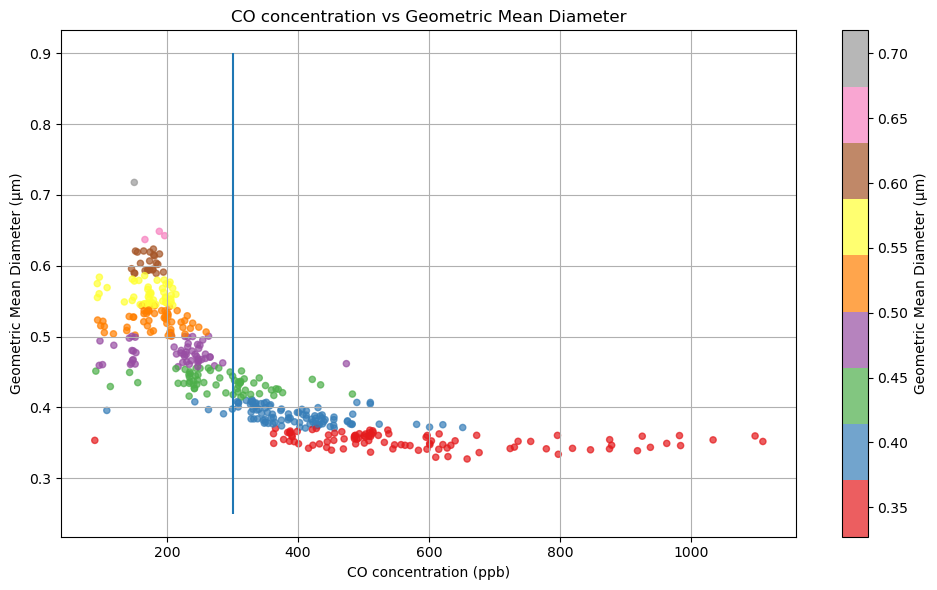

In [25]:
# Combine all flight data
combined_data = []
for entry in results_sct:
    try:
        df = pd.DataFrame({
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
            'DG': entry['DG_aligned'],
            'CO': entry['CO'],
            'Flight': entry['flight']
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)

plt.figure(figsize=(10,6))

# Scatter plot ME vs DG
sc = plt.scatter(df_all["CO"], df_all["DG"], 
                 c=df_all["DG"], cmap="Set1", s=20, alpha=0.7)
plt.vlines(300,0.25,0.9)
plt.ylabel("Geometric Mean Diameter (µm)")
plt.xlabel("CO concentration (ppb)")
plt.title("CO concentration vs Geometric Mean Diameter")
plt.colorbar(sc, label="Geometric Mean Diameter (µm)")
plt.grid(True)
plt.tight_layout()
plt.show()

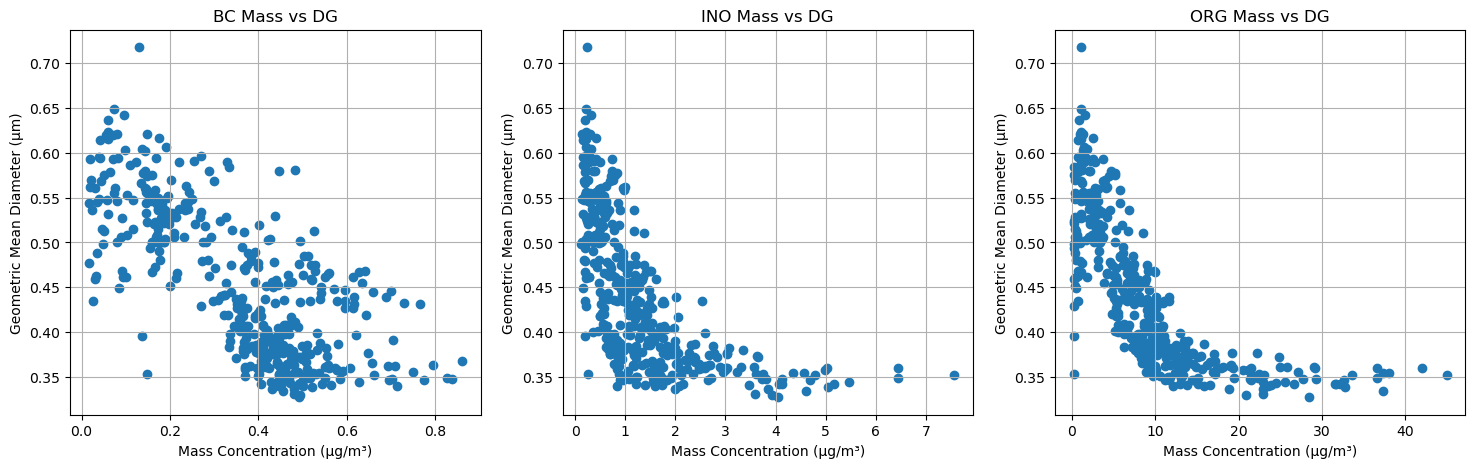

In [26]:
# Combine all flight data
combined_data = []
for entry in results_sct:
    try:
        df = pd.DataFrame({
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
            'DG': entry['DG_aligned'],
            'Flight': entry['flight']
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)

species_data = ['BC', 'INO', 'ORG']
colors = ['black', 'red', 'green']

fig, axes = plt.subplots(1, 3, figsize=(18,5))  # No shared y-axis

for ax, species, color in zip(axes, species_data, colors):
    sc = ax.scatter(df_all[species], df_all['DG'])
    ax.set_ylabel("Geometric Mean Diameter (µm)")
    ax.set_title(f"{species} Mass vs DG")
    ax.grid(True)
    ax.set_xlabel("Mass Concentration (µg/m³)")

# Single colorbar for all subplots
#cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), label="Geometric Mean Diameter (µm)")
#plt.tight_layout()
plt.show()

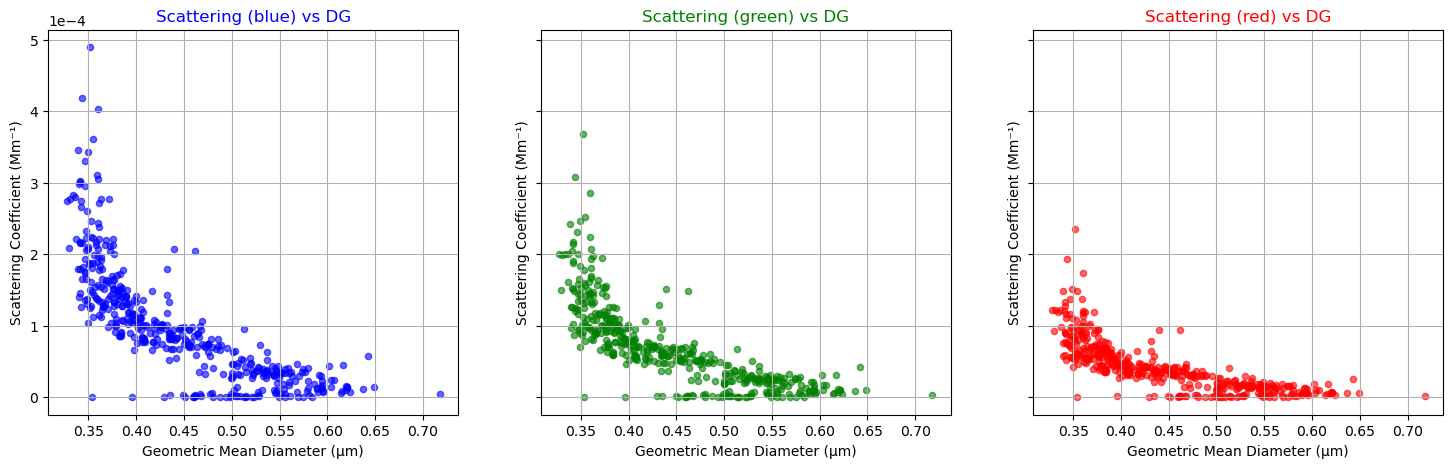

In [27]:
# Combine all flight data
combined_data = []
for entry in results_sct:
    try:
        df = pd.DataFrame({
            'TSC_blue': entry['TSC_blue'],
            'TSC_green': entry['TSC_green'],
            'TSC_red': entry['TSC_red'],
            'DG': entry['DG_aligned'],
            'Flight': entry['flight']
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)

# Wavelength scattering variables
scattering_vars = ['TSC_blue', 'TSC_green', 'TSC_red']
colors = ['blue', 'green', 'red']

fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

for ax, var, color in zip(axes, scattering_vars, colors):
    sc = ax.scatter(df_all['DG'], df_all[var], color=color, alpha=0.6, s=20)
    ax.set_xlabel("Geometric Mean Diameter (µm)")
    ax.set_title(f"Scattering ({var.split('_')[1]}) vs DG", color=color)
    ax.grid(True)
    ax.set_ylabel("Scattering Coefficient (Mm⁻¹)")  # adjust unit if needed
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.show()

In [28]:
results_sct_all = []

# Iterate over all matching flights
for sp2_file, ams_file, core_file, neph_file, cloud_file in zip(filtered_sp2, filtered_ams, filtered_core, filtered_neph,filtered_cloud):
    
    ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(sp2_file,ams_file,neph_file)
    ds_core = xr.open_dataset(core_file)

    ds_core_cloud = xr.open_dataset(cloud_file)
    da_pcasp, times_cloud, Dgs = extract_pcasp_geo_diameter(ds_core_cloud)
    
    
    ds_psap_matched,tm_psap_match,tm_psap_match_unc,test,data_masses=Nc_file_treatment_v2(ds_sp2,ds_ams,ds_core)
    ds_neph_matched_un,tm_neph_match,tm_neph_match_unc=calculate_scatering_eff_v2(ds_sp2,ds_ams,ds_neph)
    
    
    ds_psap_matched_time = test["data_point"].values  # Reference timestamps
    ds_neph_matched_time = ds_neph_matched_un["time"].values
    common_times = np.intersect1d(ds_psap_matched_time, ds_neph_matched_time)

    #Add landcover
    test = add_land_cover_nc_file(test,ds_subset)

    
    core_file_matched = test.sel(data_point=common_times)
    ds_neph_matched = ds_neph_matched_un.sel(time=common_times)
    tm_neph_match = tm_neph_match.sel(time=common_times)
    BC_mass_match = data_masses[0].sel(time=common_times)
    amonium_sulfate_nitrate_mass_match = data_masses[1].sel(time=common_times)
    ORG_mass_match = data_masses[2].sel(time=common_times)

    CO_conc_matched = core_file_matched['CO_AERO'].values.squeeze()
    TSC_blue = ds_neph_matched["TSC_BLUU"].values.squeeze()
    TSC_green = ds_neph_matched["TSC_GRNU"].values.squeeze()
    TSC_red = ds_neph_matched["TSC_REDU"].values.squeeze()
    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', core_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    
    #series = pd.Series(Dgs, index=pd.to_datetime(times))
    # Align Dg values with matched times
    series = pd.Series(Dgs, index=pd.to_datetime(times_cloud))
    # Resample to 1-minute mean
    Dgs_30s = series.resample("30s").mean()
    Dg_aligned_matched = Dgs_30s.reindex(pd.to_datetime(common_times), method="nearest")

    #Biome analysis
    biome_type_clean = core_file_matched['Biome_Type']
        
    # Create masks
    mask_forest = biome_type_clean.isin([1, 2, 3, 4, 5])
    mask_cerrado = biome_type_clean.isin([6, 7, 8, 9, 10,12])
    mask_other = ~(mask_forest | mask_cerrado)
    
    # Total valid observations
    total = len(biome_type_clean)
    
    # Count for each group
    forest_count = mask_forest.sum()
    cerrado_count = mask_cerrado.sum()
    other_count = total - (forest_count + cerrado_count)
    
    # Calculate percentages
    forest_pct = 100 * forest_count / total
    cerrado_pct = 100 * cerrado_count / total
    other_pct = 100 * other_count / total
    
    # Extract scattering values as NumPy array
    geo_dia_values = Dg_aligned_matched.values
    
    # Apply masks to get values by biome group
    forest_values = geo_dia_values[mask_forest]
    cerrado_values = geo_dia_values[mask_cerrado]
    other_values = geo_dia_values[mask_other]
    
    # Remove NaNs (optional, for cleaner boxplot)
    forest_values = forest_values[~np.isnan(forest_values)]
    cerrado_values = cerrado_values[~np.isnan(cerrado_values)]
    other_values = other_values[~np.isnan(other_values)]

    

    
    # Store results in a list
    results_sct_all.append({
        'BC': BC_mass_match.values,
        'INO': amonium_sulfate_nitrate_mass_match.values,
        'ORG': ORG_mass_match.values,
        'DG_aligned': Dg_aligned_matched,
        'CO': CO_conc_matched,
        'TSC_blue':TSC_blue,
        'TSC_green':TSC_green,
        'TSC_red':TSC_red,
        'flight': flight_number,
        "forests_pct": forest_pct,
        "cerrado_pct": cerrado_pct,
        "other_pct": other_pct,
        "forest_values": forest_values,
        "cerrado_values": cerrado_values,
        "other_values": other_values
    })


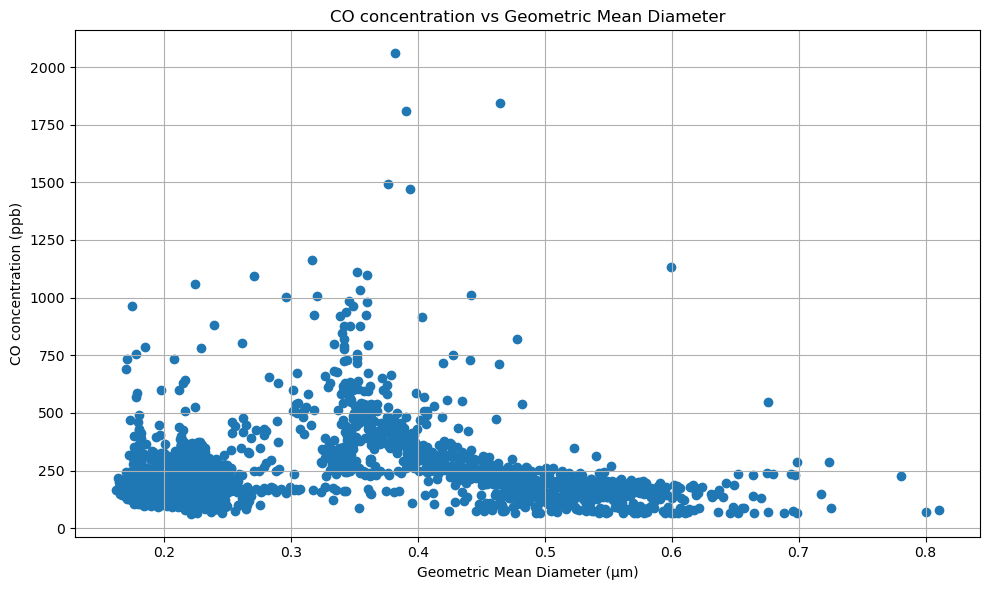

In [29]:
# Combine all flight data
combined_data = []
for entry in results_sct_all:
    try:
        df = pd.DataFrame({
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
            'DG': entry['DG_aligned'],
            'CO': entry['CO'],
            'Flight': entry['flight']
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)

plt.figure(figsize=(10,6))

# Scatter plot ME vs DG
sc = plt.scatter(df_all["DG"], df_all["CO"])
#plt.vlines(300,0.25,0.9)
plt.xlabel("Geometric Mean Diameter (µm)")
plt.ylabel("CO concentration (ppb)")
plt.title("CO concentration vs Geometric Mean Diameter")
#plt.colorbar(sc, label="Geometric Mean Diameter (µm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
# Combine all flight data
combined_data = []
for entry in results_sct_all:
    try:
        df = pd.DataFrame({
            'TSC_blue': entry['TSC_blue'],
            'TSC_green': entry['TSC_green'],
            'TSC_red': entry['TSC_red'],
            'DG': entry['DG_aligned'],
            'Flight': entry['flight'],
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)


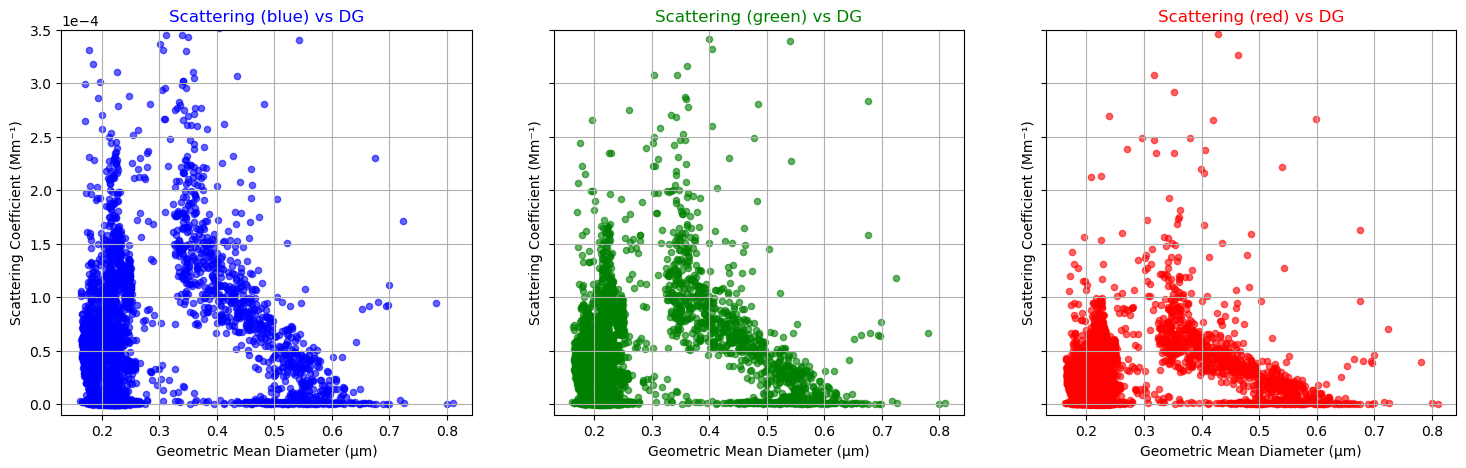

In [31]:
# Wavelength scattering variables
scattering_vars = ['TSC_blue', 'TSC_green', 'TSC_red']
colors = ['blue', 'green', 'red']

fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

for ax, var, color in zip(axes, scattering_vars, colors):
    sc = ax.scatter(df_all['DG'], df_all[var], color=color, alpha=0.6, s=20)
    ax.set_xlabel("Geometric Mean Diameter (µm)")
    ax.set_title(f"Scattering ({var.split('_')[1]}) vs DG", color=color)
    ax.grid(True)
    ax.set_ylabel("Scattering Coefficient (Mm⁻¹)")  # adjust unit if needed
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.set_ylim(-0.01e-3,0.35e-3)

plt.show()

/tmp/ipykernel_374/2634746564.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(flights))


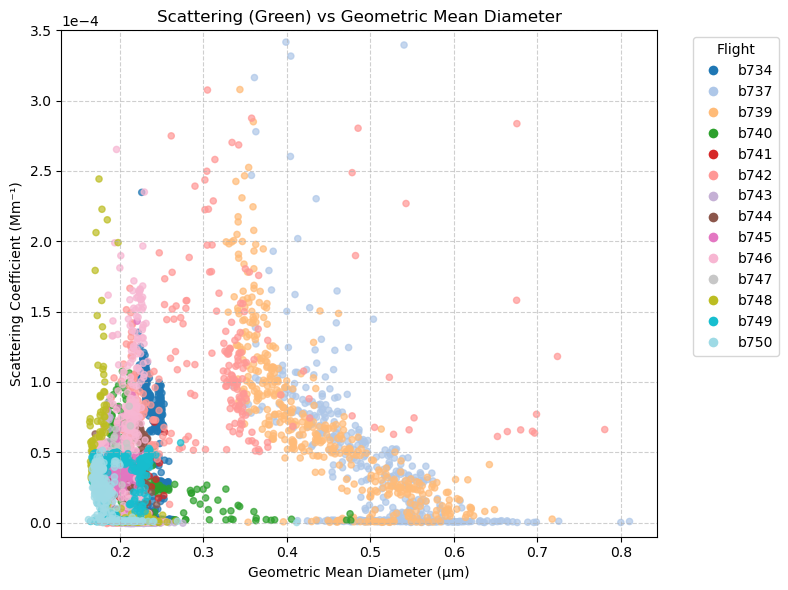

In [48]:

plt.figure(figsize=(8,6))

# Unique flight IDs
flights = df_all['Flight'].unique()

# Build a discrete colormap with as many colors as flights
cmap = cm.get_cmap('tab20', len(flights))
color_map = {flight: cmap(i) for i, flight in enumerate(flights)}

# Map flight strings to colors
colors = df_all['Flight'].map(color_map)

# Scatter plot
sc = plt.scatter(
    df_all['DG'], df_all['TSC_green'],
    c=colors, alpha=0.7, s=20
)

# Custom legend (since flights are categorical)
handles = [plt.Line2D([0],[0], marker='o', color='w',
                      markerfacecolor=color_map[flight], markersize=8)
           for flight in flights]
plt.legend(handles, flights, title="Flight", bbox_to_anchor=(1.05, 1), loc='upper left')

# Labels and formatting
plt.xlabel("Geometric Mean Diameter (µm)")
plt.ylabel("Scattering Coefficient (Mm⁻¹)")
plt.title("Scattering (Green) vs Geometric Mean Diameter")
plt.grid(True, linestyle="--", alpha=0.6)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ylim(-0.01e-3, 0.35e-3)

plt.tight_layout()
plt.show()

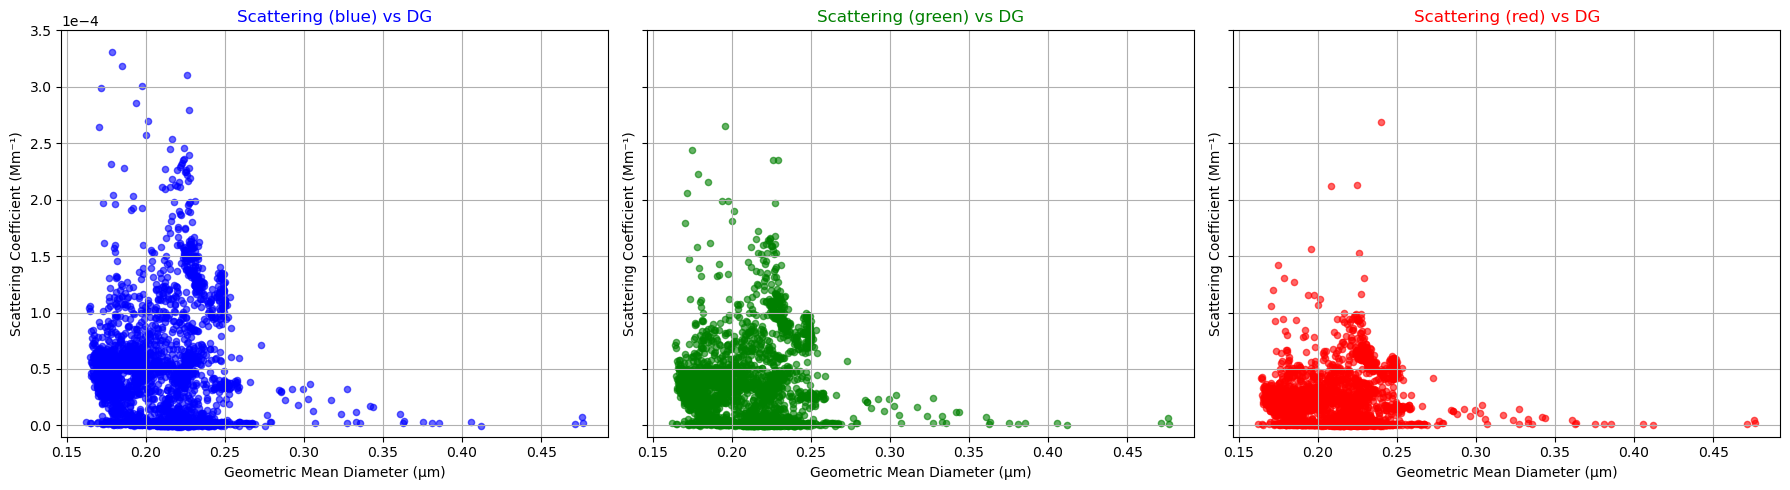

In [51]:
# Flights to exclude
exclude_flights = ["b739", "b737", "b742"]

# Filter the DataFrame
df_filtered = df_all[~df_all["Flight"].isin(exclude_flights)]

# Wavelength scattering variables
scattering_vars = ['TSC_blue', 'TSC_green', 'TSC_red']
colors = ['blue', 'green', 'red']

fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

for ax, var, color in zip(axes, scattering_vars, colors):
    sc = ax.scatter(df_filtered['DG'], df_filtered[var], color=color, alpha=0.6, s=20)
    ax.set_xlabel("Geometric Mean Diameter (µm)")
    ax.set_title(f"Scattering ({var.split('_')[1]}) vs DG", color=color)
    ax.grid(True)
    ax.set_ylabel("Scattering Coefficient (Mm⁻¹)")
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.set_ylim(-0.01e-3, 0.35e-3)

plt.tight_layout()
plt.show()


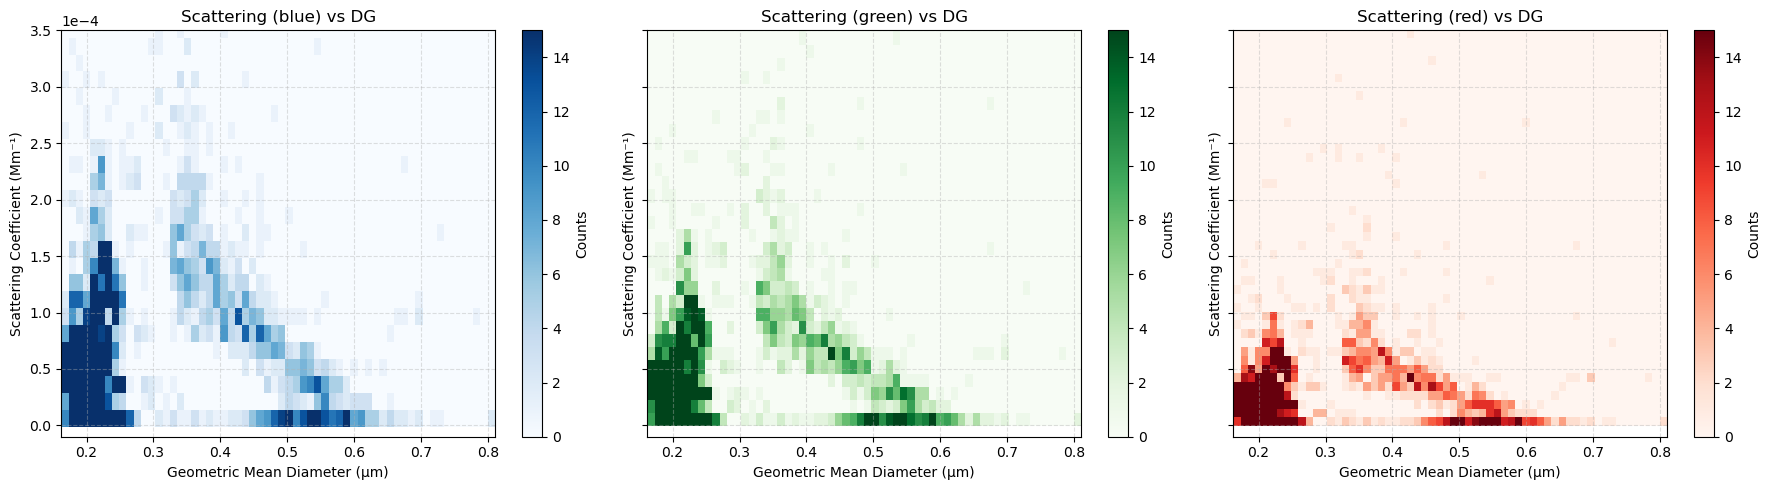

In [32]:
# Wavelength scattering variables
scattering_vars = ['TSC_blue', 'TSC_green', 'TSC_red']
cmaps = ['Blues', 'Greens', 'Reds']

# Set color limits
cbar_min = 0        # minimum count shown
cbar_max = 15      # maximum count for color saturation

fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

for ax, var, cmap in zip(axes, scattering_vars, cmaps):
    # Clean data: remove NaNs/infs
    df_plot = df_all[['DG', var]].replace([np.inf, -np.inf], np.nan).dropna()
    if df_plot.empty:
        ax.text(0.5, 0.5, f'No finite data for {var}', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    x = df_plot['DG'].values
    y = df_plot[var].values

    # Histogram
    H, xedges, yedges = np.histogram2d(x, y, bins=[60,120])
    
    pcm = ax.pcolormesh(xedges, yedges, H.T, cmap=cmap, shading='auto', vmin=cbar_min, vmax=cbar_max)
    cbar = fig.colorbar(pcm, ax=ax, label='Counts')
    
    ax.set_xlabel("Geometric Mean Diameter (µm)")
    ax.set_ylabel("Scattering Coefficient (Mm⁻¹)")
    ax.set_title(f"Scattering ({var.split('_')[1]}) vs DG")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.set_ylim(-0.01e-3,0.35e-3)

plt.tight_layout()
plt.show()

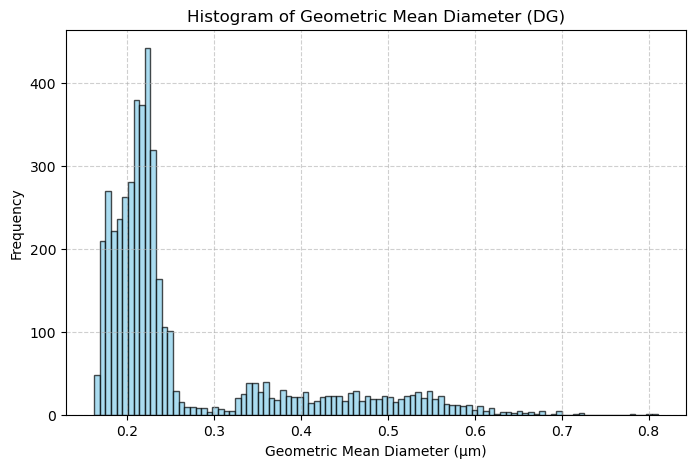

In [33]:
# Concatenate all flights
df_all = pd.concat(combined_data)

# Histogram of DG
plt.figure(figsize=(8,5))
plt.hist(df_all['DG'].dropna(), bins=100, color="skyblue", edgecolor="black", alpha=0.7)
plt.xlabel("Geometric Mean Diameter (µm)")
plt.ylabel("Frequency")
plt.title("Histogram of Geometric Mean Diameter (DG)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


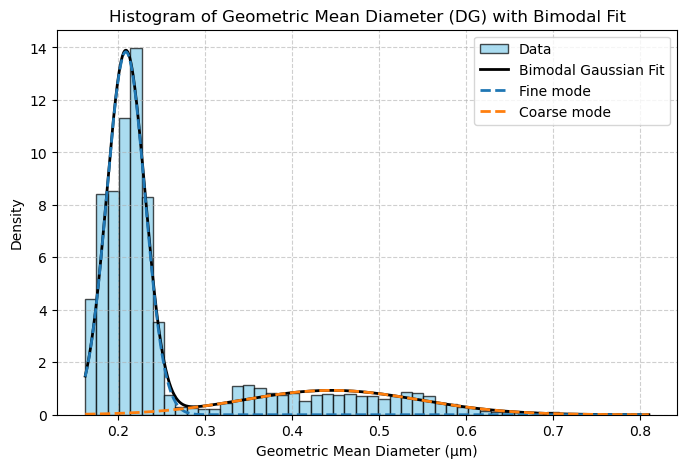

Fine mode: mean=0.209, std=0.022, weight=0.763
Coarse mode: mean=0.445, std=0.102, weight=0.237


In [34]:


# Concatenate all flights
df_all = pd.concat(combined_data)
values = df_all['DG'].dropna().values.reshape(-1, 1)

# Fit Gaussian Mixture with 2 components (bimodal)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(values)

# Extract parameters
means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_).flatten()
weights = gmm.weights_.flatten()

# Order them: fine mode = smaller mean, coarse mode = larger mean
sorted_idx = np.argsort(means)
means = means[sorted_idx]
stds = stds[sorted_idx]
weights = weights[sorted_idx]
labels = ["Fine mode", "Coarse mode"]

# Histogram (normalized)
plt.figure(figsize=(8,5))
counts, bins, patches = plt.hist(values, bins=50, color="skyblue", edgecolor="black", alpha=0.7, density=True, label="Data")

# Evaluate GMM PDF
x = np.linspace(values.min(), values.max(), 1000).reshape(-1,1)
logprob = gmm.score_samples(x)
pdf = np.exp(logprob)

# Individual Gaussian components
pdf_individual = [w * 1/(s*np.sqrt(2*np.pi)) * np.exp(-0.5*((x-m)/s)**2)
                  for w, m, s in zip(weights, means, stds)]

# Plot mixture fit
plt.plot(x, pdf, 'k-', lw=2, label="Bimodal Gaussian Fit")

# Plot individual components with labels
for lbl, comp in zip(labels, pdf_individual):
    plt.plot(x, comp, '--', lw=2, label=lbl)

# Labels and grid
plt.xlabel("Geometric Mean Diameter (µm)")
plt.ylabel("Density")
plt.title("Histogram of Geometric Mean Diameter (DG) with Bimodal Fit")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# Print parameters with labels
for lbl, m, s, w in zip(labels, means, stds, weights):
    print(f"{lbl}: mean={m:.3f}, std={s:.3f}, weight={w:.3f}")


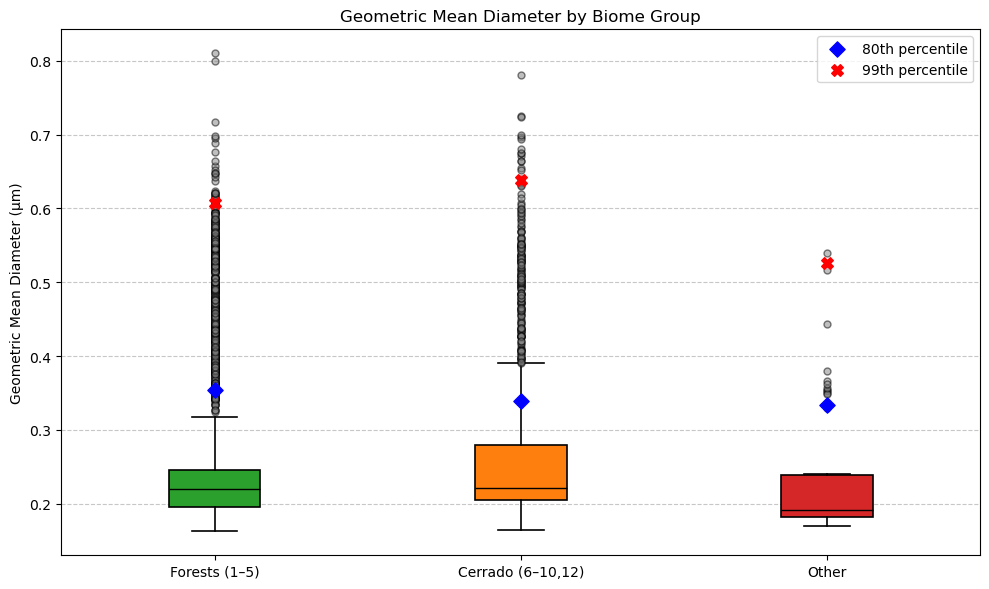

In [35]:
# Initialize lists to hold values from all flights
all_forest_values = []
all_cerrado_values = []
all_other_values = []

for res in results_sct_all:
    all_forest_values.extend(res["forest_values"])
    all_cerrado_values.extend(res["cerrado_values"])
    all_other_values.extend(res["other_values"])
    
# Colors
color_forest = "#2ca02c"   # green
color_cerrado = "#ff7f0e"  # orange
color_other = "#d62728"    # red

# Data and labels
data = [all_forest_values, all_cerrado_values, all_other_values]
labels = ['Forests (1–5)', 'Cerrado (6–10,12)', 'Other']
colors = [color_forest, color_cerrado, color_other]

# Plot
plt.figure(figsize=(10, 6))
box = plt.boxplot(data, tick_labels=labels, patch_artist=True,
                  medianprops=dict(color='black'),
                  boxprops=dict(linewidth=1.2),
                  whiskerprops=dict(linewidth=1.2),
                  capprops=dict(linewidth=1.2),
                  flierprops=dict(marker='o', markersize=5, markerfacecolor='gray', alpha=0.5))

# Apply colors to each box
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Add 80th and 90th percentiles with higher z-order
for i, values in enumerate(data, start=1):
    if len(values) > 0:  # avoid error if empty
        p80 = np.percentile(values, 80)
        p90 = np.percentile(values, 99)
        plt.scatter(i, p80, color="blue", marker="D", s=60,
                    zorder=10, label="80th percentile" if i == 1 else "")
        plt.scatter(i, p90, color="red", marker="X", s=70,
                    zorder=10, label="99th percentile" if i == 1 else "")

plt.title("Geometric Mean Diameter by Biome Group")
plt.ylabel("Geometric Mean Diameter (µm)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend only once
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()


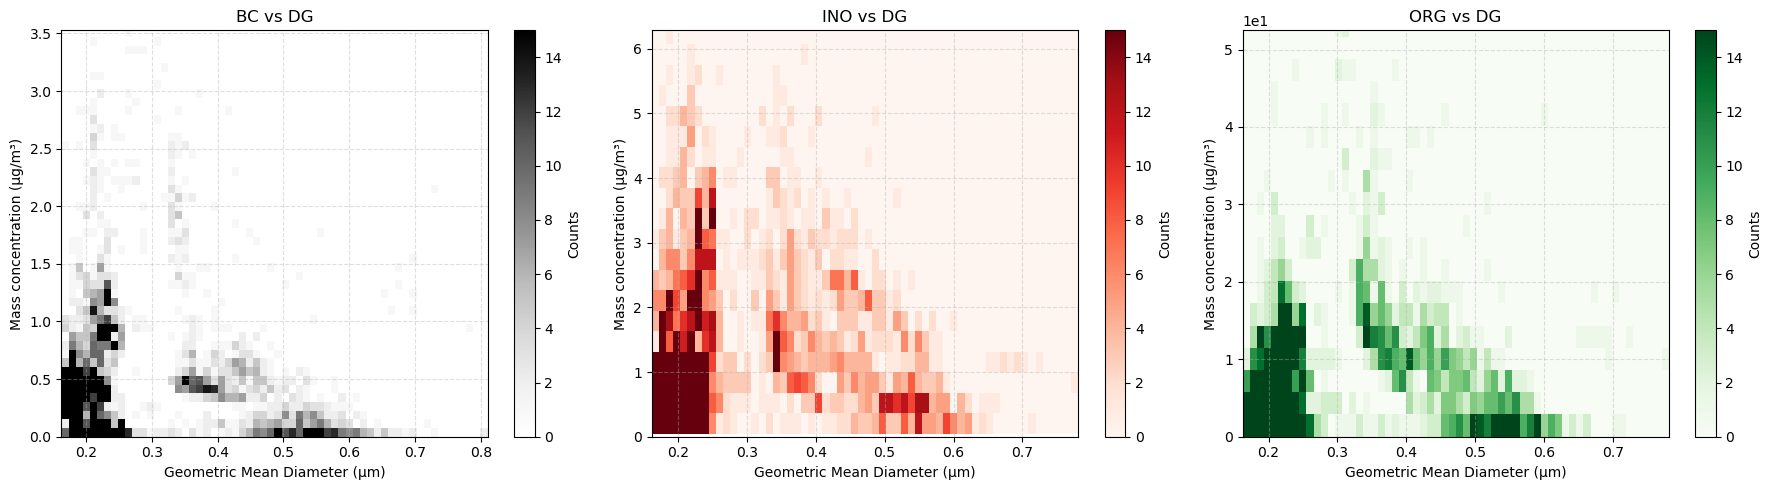

In [36]:
# Mass variables
mass_vars = ['BC', 'INO', 'ORG']
cmaps = ['Greys', 'Reds', 'Greens']

# Set color limits for the 2D hist
cbar_min = 0
cbar_max = 15

fig, axes = plt.subplots(1, 3, figsize=(18,5))  # no sharey

for ax, var, cmap in zip(axes, mass_vars, cmaps):
    # Clean data: remove NaNs/infs
    df_plot = df_all[['DG', var]].replace([np.inf, -np.inf], np.nan).dropna()
    if df_plot.empty:
        ax.text(0.5, 0.5, f'No finite data for {var}', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    x = df_plot['DG'].values
    y = df_plot[var].values

    # 2D histogram
    H, xedges, yedges = np.histogram2d(x, y, bins=[60,120])

    pcm = ax.pcolormesh(xedges, yedges, H.T, cmap=cmap, shading='auto',
                        vmin=cbar_min, vmax=cbar_max)
    cbar = fig.colorbar(pcm, ax=ax, label='Counts')

    # Axis labels
    ax.set_xlabel("Geometric Mean Diameter (µm)")
    ax.set_ylabel("Mass concentration (µg/m³)")
    ax.set_title(f"{var} vs DG")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    # Set ylim based on 90th percentile
    p90 = np.percentile(y, 99)
    ax.set_ylim(0, p90 * 1.1)  # add 10% padding

plt.tight_layout()
plt.show()


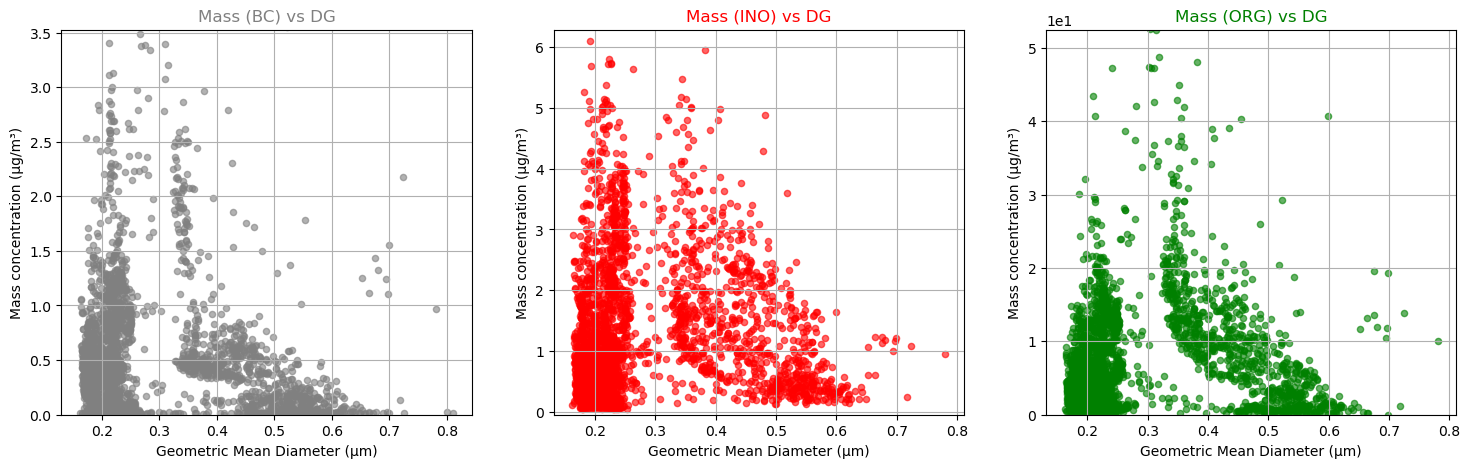

In [37]:
# Wavelength scattering variables
mass_vars = ['BC', 'INO', 'ORG']
colors = ['gray', 'red', 'green']

fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=False)

for ax, var, color in zip(axes, mass_vars, colors):
    df_plot = df_all[['DG', var]].replace([np.inf, -np.inf], np.nan).dropna()
    x = df_plot['DG'].values
    y = df_plot[var].values
    sc = ax.scatter(x, y, color=color, alpha=0.6, s=20)
    ax.set_xlabel("Geometric Mean Diameter (µm)")
    ax.set_title(f"Mass ({var}) vs DG", color=color)
    ax.grid(True)
    ax.set_ylabel("Mass concentration (µg/m³)")  # adjust unit if needed
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    #ax.set_ylim(-0.01e-3,0.35e-3)
    # Set ylim based on 90th percentile
    p90 = np.percentile(y, 99)
    p0 = np.percentile(y, 0)
    ax.set_ylim(p0*-1.1, p90 * 1.1)  # add 10% padding

plt.show()